In [1]:
import sys
import os

sys.path.append(os.path.abspath("..")) 

from src.data_loader import DataLoader

loader = DataLoader()
df = loader.unify_datasets()

df.head()
df.shape
df['label'].value_counts()

label
1    23481
0    21417
Name: count, dtype: int64

In [2]:
from src.preprocessing import DataCleaner

cleaner = DataCleaner(min_words=30)
clean_df = cleaner.clean(df)

print("Before:", df.shape)
print("After:", clean_df.shape)

Before: (44898, 3)
After: (38010, 3)


In [3]:
df.isnull().sum()

text              0
label             0
source_dataset    0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(6251)

In [5]:
clean_df["label"].value_counts()
clean_df["label"].value_counts(normalize=True)

label
0    0.55688
1    0.44312
Name: proportion, dtype: float64

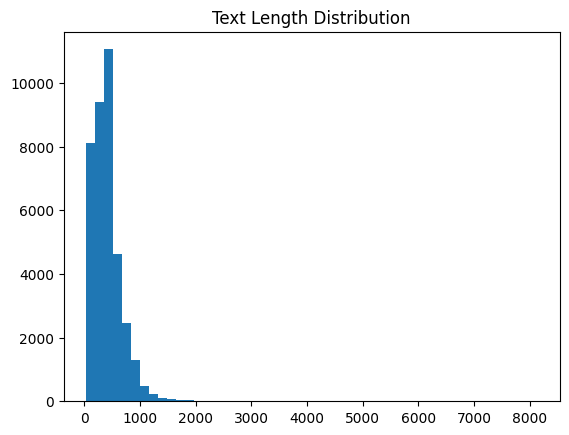

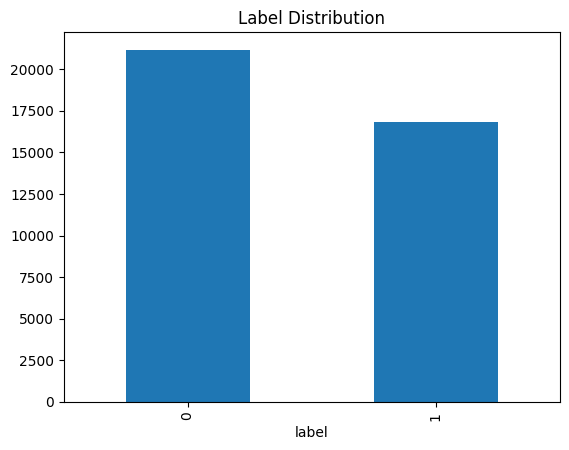

In [6]:
import matplotlib.pyplot as plt

# Text length distribution
clean_df["text_length"] = clean_df["text"].str.split().str.len()

plt.hist(clean_df["text_length"], bins=50)
plt.title("Text Length Distribution")
plt.show()

# Label distribution
clean_df["label"].value_counts().plot(kind="bar")
plt.title("Label Distribution")
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

X = clean_df["text"]
y = clean_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

print("Train distribution:")
print(y_train.value_counts(normalize=True))

print("Test distribution:")
print(y_test.value_counts(normalize=True))

Train size: 30408
Test size: 7602
Train distribution:
label
0    0.556893
1    0.443107
Name: proportion, dtype: float64
Test distribution:
label
0    0.556827
1    0.443173
Name: proportion, dtype: float64


In [8]:
from src.text_preprocessor import TextPreprocessor

basic_processor = TextPreprocessor(use_lemmatization=False)
advanced_processor = TextPreprocessor(use_lemmatization=True)

sample_text = X_train.iloc[0]

print("Original:\n", sample_text[:300])
print("\nBasic Clean:\n", basic_processor.preprocess(sample_text)[:300])
print("\nAdvanced Clean:\n", advanced_processor.preprocess(sample_text)[:300])

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\preet\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Original:
 (Reuters) - Highlights of the day for U.S. President Donald Trump’s administration on Friday: Trump says he will make a massive budget request for one of the “greatest military buildups in American history” in a feisty, campaign-style speech extolling robust nationalism to eager conservative activis

Basic Clean:
 reuters highlights day us president donald trumps administration friday trump says make massive budget request one greatest military buildups american history feisty campaignstyle speech extolling robust nationalism eager conservative activists trump signs executive order aimed repealing simplifying

Advanced Clean:
 reuters highlight day us president donald trumps administration friday trump say make massive budget request one great military buildup american history feisty campaignstyle speech extoll robust nationalism eager conservative activist trump sign executive order aim repeal simplify federal regulation


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

In [10]:
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words=None
)

In [11]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [12]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [13]:
y_pred = model.predict(X_test_tfidf)
y_proba = model.predict_proba(X_test_tfidf)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99      4233
           1       0.99      0.98      0.99      3369

    accuracy                           0.99      7602
   macro avg       0.99      0.99      0.99      7602
weighted avg       0.99      0.99      0.99      7602

ROC-AUC: 0.9986993177255667


In [14]:
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_[0]

top_fake_indices = coefficients.argsort()[-20:]
top_real_indices = coefficients.argsort()[:20]

print("Top words pushing toward FAKE:")
for i in reversed(top_fake_indices):
    print(feature_names[i])

print("\nTop words pushing toward REAL:")
for i in top_real_indices:
    print(feature_names[i])
    

Top words pushing toward FAKE:
via
this
read more
us
is
just
that
image
read
featured image
featured
gop
mr
image via
president trump
com
you
the us
hillary
watch

Top words pushing toward REAL:
reuters
said
on
washington reuters
said on
reuters the
washington
on tuesday
on wednesday
president donald
in
republican
on thursday
on friday
reuters president
on monday
said in
edt
minister
tuesday
